### Creating all the figures

In [23]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════

RESULTS_DIR = "./results"

FIGURE_DIR = "./figures_final_pipeline"
os.makedirs(FIGURE_DIR, exist_ok=True)

CLASSIFIERS = ["svm", "gru", "patchtst", "inceptiontime"]

CLASSIFIER_LABELS = {
    "svm": "SVM",
    "gru": "GRU",
    "patchtst": "PatchTST",
    "inceptiontime": "InceptionTime",
}

sns.set_theme(style="whitegrid", context="paper")

print("Current working directory:", os.getcwd())
print("Results directory:", os.path.abspath(RESULTS_DIR))
print("Results directory exists:", os.path.exists(RESULTS_DIR))

txt_files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".txt")])
print("Number of txt files:", len(txt_files))
print("First 10 files:")
for f in txt_files[:10]:
    print(" ", f)


# ══════════════════════════════════════════════════════════════
# RESULT CATEGORIES
# ══════════════════════════════════════════════════════════════

result_categories = {
    "1_normalization": {
        "title": "Impact of Normalization",
        "short_label": "Normalization",
        "methods": [
            ("No Norm", "nonorm"),
            ("Z-score", "zscore_all"),
            ("Min-max", "minmax_all"),
            ("Log", "log_all"),
            ("Hybrid", "hybrid"),
        ],
    },

    "2_timespan_reduction_removed": {
        "title": "Impact of Time-span Reduction",
        "short_label": "Time-span\nreduction",
        "methods": [
            ("6 h", "hybrid_6h"),
            ("9 h", "hybrid_9h"),
            ("12 h", "hybrid_12h"),
            ("18 h", "hybrid_18h"),
            ("Full", "hybrid"),
        ],
    },

    "3_borderline_cleaning": {
        "title": "Impact of Borderline Cleaning",
        "short_label": "Borderline\ncleaning",
        "methods": [
            ("Hybrid baseline", "hybrid"),
            ("ENN", "hybrid_enn"),
            ("Tomek Links", "hybrid_tomek"),
            ("NearMiss", "hybrid_nearmiss"),
        ],
    },

    "4_random_undersampling": {
        "title": "Impact of Random Undersampling",
        "short_label": "Random\nundersampling",
        "methods": [
            ("ENN baseline", "hybrid_enn"),
            ("RUS 8000", "enn_nonsep_8000"),
            ("RUS 4000", "enn_nonsep_4000"),
            ("RUS 2000", "enn_nonsep_2000"),
            ("RUS 1000", "enn_nonsep_1000"),
            ("RUS 500", "enn_nonsep_500"),
        ],
    },

    "5_oversampling_and_rus": {
        "title": "Impact of Oversampling and RUS",
        "short_label": "Oversampling\n+ RUS",
        "methods": [
            # SMOTE
            ("SMOTE balanced", "enn_smote_balanced"),
            ("SMOTE 8000", "enn_rus8000_smote8000"),
            ("SMOTE 4000", "enn_rus4000_smote4000"),
            ("SMOTE 2000", "enn_rus2000_smote2000"),
            ("SMOTE 1000", "enn_rus1000_smote1000"),
            ("SMOTE 500", "enn_rus500_smote500"),

            # ADASYN
            ("ADASYN balanced", "enn_adasyn_balanced"),
            ("ADASYN 8000", "enn_rus8000_adasyn8000"),
            ("ADASYN 4000", "enn_rus4000_adasyn4000"),
            ("ADASYN 2000", "enn_rus2000_adasyn2000"),
            ("ADASYN 1000", "enn_rus1000_adasyn1000"),
            ("ADASYN 500", "enn_rus500_adasyn500"),

            # TimeGAN
            ("TimeGAN balanced", "timegan_balanced"),
            ("TimeGAN 8000", "timegan_8000"),
            ("TimeGAN 4000", "timegan_4000"),
            ("TimeGAN 2000", "timegan_2000"),
            ("TimeGAN 1000", "timegan_1000"),
            ("TimeGAN 500", "timegan_500"),
        ],
    },
}

CATEGORY_ORDER = list(result_categories.keys())

Current working directory: /Users/samskanderi/SEP_DataAugmentation
Results directory: /Users/samskanderi/SEP_DataAugmentation/results
Results directory exists: True
Number of txt files: 140
First 10 files:
  gru_enn_adasyn_balanced.txt
  gru_enn_nonsep_1000.txt
  gru_enn_nonsep_2000.txt
  gru_enn_nonsep_4000.txt
  gru_enn_nonsep_500.txt
  gru_enn_nonsep_8000.txt
  gru_enn_rus1000_adasyn1000.txt
  gru_enn_rus1000_smote1000.txt
  gru_enn_rus2000_adasyn2000.txt
  gru_enn_rus2000_smote2000.txt


In [24]:
# ══════════════════════════════════════════════════════════════
# READ RESULT FILES
# Saved format:
# TP,TN,FP,FN,tss,hss1,hss2,gss,recall,f1,accuracy,train_time,infer_time
# ══════════════════════════════════════════════════════════════

def read_result_file_csv_style(filepath):
    rows = []

    with open(filepath, "r") as f:
        lines = f.readlines()

    for run_idx, line in enumerate(lines, start=1):
        line = line.strip()

        if not line:
            continue

        parts = line.split(",")

        if len(parts) < 13:
            print(f"Skipping malformed line in {filepath}: {line}")
            continue

        row = {
            "run": run_idx,
            "TP": int(float(parts[0])),
            "TN": int(float(parts[1])),
            "FP": int(float(parts[2])),
            "FN": int(float(parts[3])),
            "tss": float(parts[4]),
            "hss1": float(parts[5]),
            "hss2": float(parts[6]),
            "gss": float(parts[7]),
            "recall": float(parts[8]),
            "f1": float(parts[9]),
            "accuracy": float(parts[10]),
            "train_time": float(parts[11]),
            "infer_time": float(parts[12]),
        }

        rows.append(row)

    return rows


# ══════════════════════════════════════════════════════════════
# BUILD FULL RESULTS DATAFRAME
# One row = one run for one classifier/method/category
# ══════════════════════════════════════════════════════════════

rows = []
found_files = []
missing_files = []
empty_files = []

for category_key, category_info in result_categories.items():

    category_title = category_info["title"]
    category_short = category_info["short_label"]

    for classifier in CLASSIFIERS:

        for method_label, file_key in category_info["methods"]:

            filename = f"{classifier}_{file_key}.txt"
            filepath = os.path.join(RESULTS_DIR, filename)

            if not os.path.exists(filepath):
                missing_files.append(filename)
                continue

            found_files.append(filename)

            file_rows = read_result_file_csv_style(filepath)

            if len(file_rows) == 0:
                empty_files.append(filename)
                continue

            for r in file_rows:
                rows.append({
                    "category_key": category_key,
                    "category": category_title,
                    "category_short": category_short,
                    "classifier": classifier,
                    "classifier_label": CLASSIFIER_LABELS[classifier],
                    "method": method_label,
                    "file_key": file_key,
                    "filename": filename,
                    **r
                })

results_df = pd.DataFrame(rows)

print("Found matching files:", len(found_files))
print("Missing files:", len(missing_files))
print("Empty files:", len(empty_files))
print("Total run-level rows:", len(results_df))

print("\nDataframe preview:")
print(results_df.head())

results_df.to_csv(os.path.join(FIGURE_DIR, "all_pipeline_run_level_results.csv"), index=False)

Found matching files: 152
Missing files: 0
Empty files: 0
Total run-level rows: 304

Dataframe preview:
      category_key                 category category_short classifier  \
0  1_normalization  Impact of Normalization  Normalization        svm   
1  1_normalization  Impact of Normalization  Normalization        svm   
2  1_normalization  Impact of Normalization  Normalization        svm   
3  1_normalization  Impact of Normalization  Normalization        svm   
4  1_normalization  Impact of Normalization  Normalization        svm   

  classifier_label   method    file_key            filename  run  TP  ...  FN  \
0              SVM  No Norm      nonorm      svm_nonorm.txt    1  15  ...  19   
1              SVM  No Norm      nonorm      svm_nonorm.txt    2  15  ...  19   
2              SVM  Z-score  zscore_all  svm_zscore_all.txt    1  20  ...  14   
3              SVM  Z-score  zscore_all  svm_zscore_all.txt    2  20  ...  14   
4              SVM  Min-max  minmax_all  svm_minmax_

In [25]:
# ══════════════════════════════════════════════════════════════
# LONG FORMAT FOR TSS AND RECALL
# One row = one metric value
# ══════════════════════════════════════════════════════════════

plot_df = results_df.melt(
    id_vars=[
        "category_key",
        "category",
        "category_short",
        "classifier",
        "classifier_label",
        "method",
        "file_key",
        "filename",
        "run"
    ],
    value_vars=["tss", "recall"],
    var_name="metric",
    value_name="score"
)

plot_df["metric"] = plot_df["metric"].map({
    "tss": "TSS",
    "recall": "Recall"
})

plot_df["category_key"] = pd.Categorical(
    plot_df["category_key"],
    categories=CATEGORY_ORDER,
    ordered=True
)

print(plot_df.head())
print("Total plot rows:", len(plot_df))

plot_df.to_csv(os.path.join(FIGURE_DIR, "all_pipeline_tss_recall_long.csv"), index=False)

      category_key                 category category_short classifier  \
0  1_normalization  Impact of Normalization  Normalization        svm   
1  1_normalization  Impact of Normalization  Normalization        svm   
2  1_normalization  Impact of Normalization  Normalization        svm   
3  1_normalization  Impact of Normalization  Normalization        svm   
4  1_normalization  Impact of Normalization  Normalization        svm   

  classifier_label   method    file_key            filename  run metric  \
0              SVM  No Norm      nonorm      svm_nonorm.txt    1    TSS   
1              SVM  No Norm      nonorm      svm_nonorm.txt    2    TSS   
2              SVM  Z-score  zscore_all  svm_zscore_all.txt    1    TSS   
3              SVM  Z-score  zscore_all  svm_zscore_all.txt    2    TSS   
4              SVM  Min-max  minmax_all  svm_minmax_all.txt    1    TSS   

      score  
0  0.148127  
1  0.148127  
2  0.500292  
3  0.500292  
4  0.505307  
Total plot rows: 608


Normalization figure rows: 80
Saved PDF: ./figures_final_pipeline/normalization_effect_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/normalization_effect_sep_prediction.png


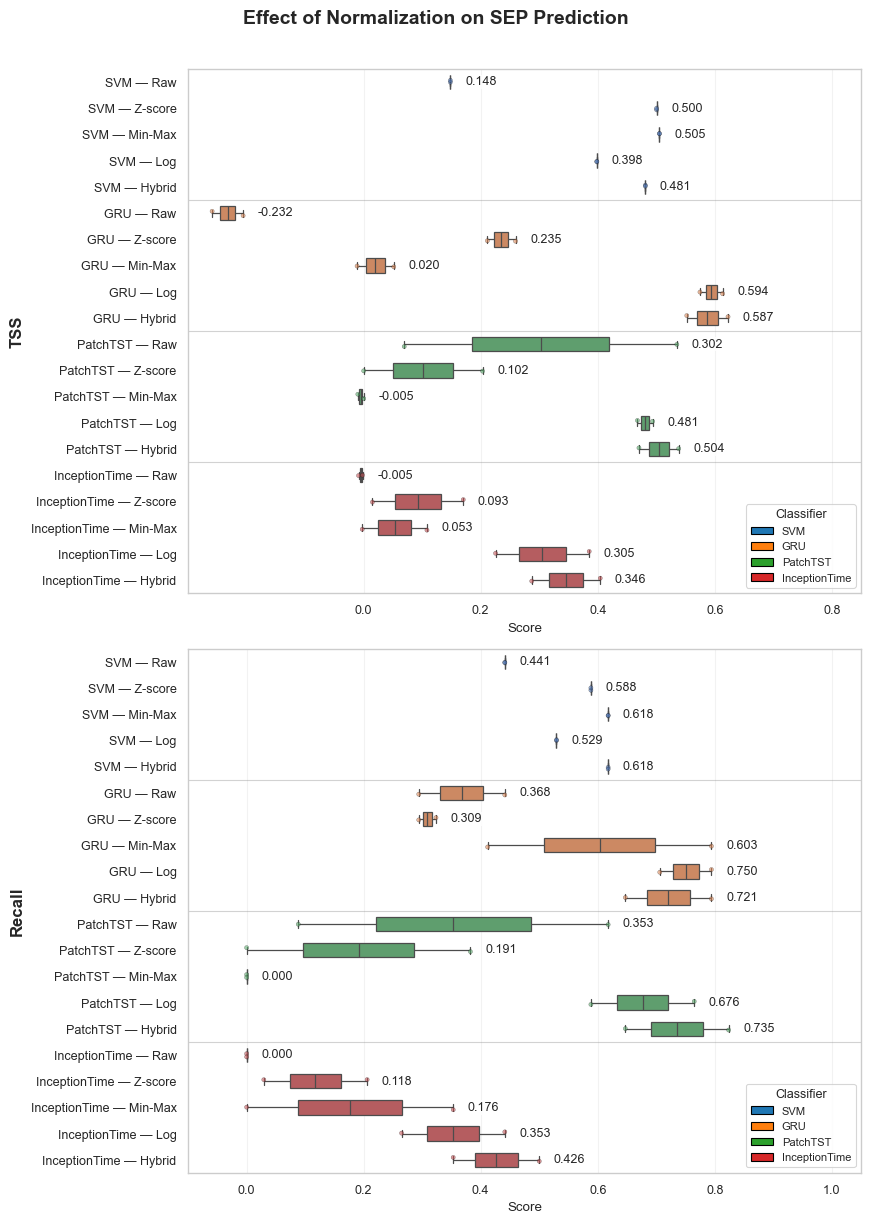

In [26]:
# ══════════════════════════════════════════════════════════════
# NORMALIZATION EFFECT
# Uses existing plot_df only
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

figure_key = "1_normalization"

figure_df = plot_df[
    plot_df["category_key"] == figure_key
].copy()

figure_df["method"] = figure_df["method"].replace({
    "Min-max": "Min-Max",
    "No Norm": "Raw"
})

method_order = [
    "Raw",
    "Z-score",
    "Min-Max",
    "Log",
    "Hybrid"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

group_order = []
for clf in classifier_order:
    for method in method_order:
        group_order.append(f"{clf} — {method}")

figure_df["group_label"] = (
    figure_df["classifier_label"].astype(str)
    + " — "
    + figure_df["method"].astype(str)
)

figure_df["group_label"] = pd.Categorical(
    figure_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Normalization figure rows:", len(figure_df))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8.8, 12.5),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = figure_df[
        figure_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.55,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=3,
        alpha=0.55,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("group_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.3, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=9.0,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.80,
                    pad=0.9
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    # Separator after each classifier block.
    # Now each classifier has 5 normalization methods.
    for sep in [4.5, 9.5, 14.5]:
        ax.axhline(
            sep,
            color="gray",
            linewidth=0.8,
            alpha=0.35
        )

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Effect of Normalization on SEP Prediction",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "normalization_effect_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "normalization_effect_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Time-span figure rows: 80
Saved PDF: ./figures_final_pipeline/time_span_effect_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/time_span_effect_sep_prediction.png


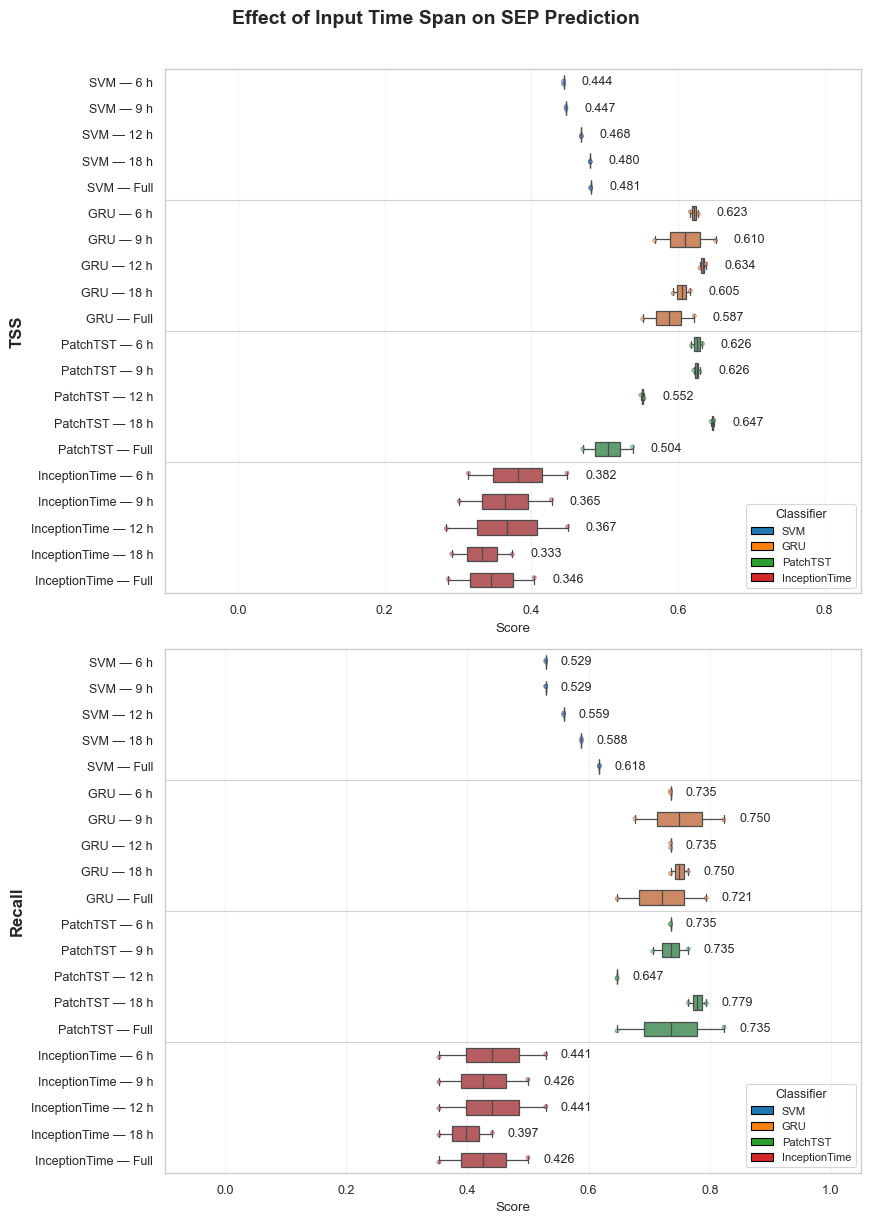

In [27]:
# ══════════════════════════════════════════════════════════════
# TIME-SPAN EFFECT
# Uses existing plot_df only
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

figure_key = "2_timespan_reduction_removed"

figure_df = plot_df[
    plot_df["category_key"] == figure_key
].copy()

method_order = [
    "6 h",
    "9 h",
    "12 h",
    "18 h",
    "Full"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

group_order = []
for clf in classifier_order:
    for method in method_order:
        group_order.append(f"{clf} — {method}")

figure_df["group_label"] = (
    figure_df["classifier_label"].astype(str)
    + " — "
    + figure_df["method"].astype(str)
)

figure_df["group_label"] = pd.Categorical(
    figure_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Time-span figure rows:", len(figure_df))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8.8, 12.5),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = figure_df[
        figure_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.55,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=3,
        alpha=0.55,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("group_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.1, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=9.0,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.80,
                    pad=0.9
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    group_size = len(method_order)
    for sep in [group_size - 0.5, 2 * group_size - 0.5, 3 * group_size - 0.5]:
        ax.axhline(
            sep,
            color="gray",
            linewidth=0.8,
            alpha=0.35
        )

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Effect of Input Time Span on SEP Prediction",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "time_span_effect_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "time_span_effect_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Borderline cleaning figure rows: 64
Saved PDF: ./figures_final_pipeline/borderline_cleaning_effect_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/borderline_cleaning_effect_sep_prediction.png


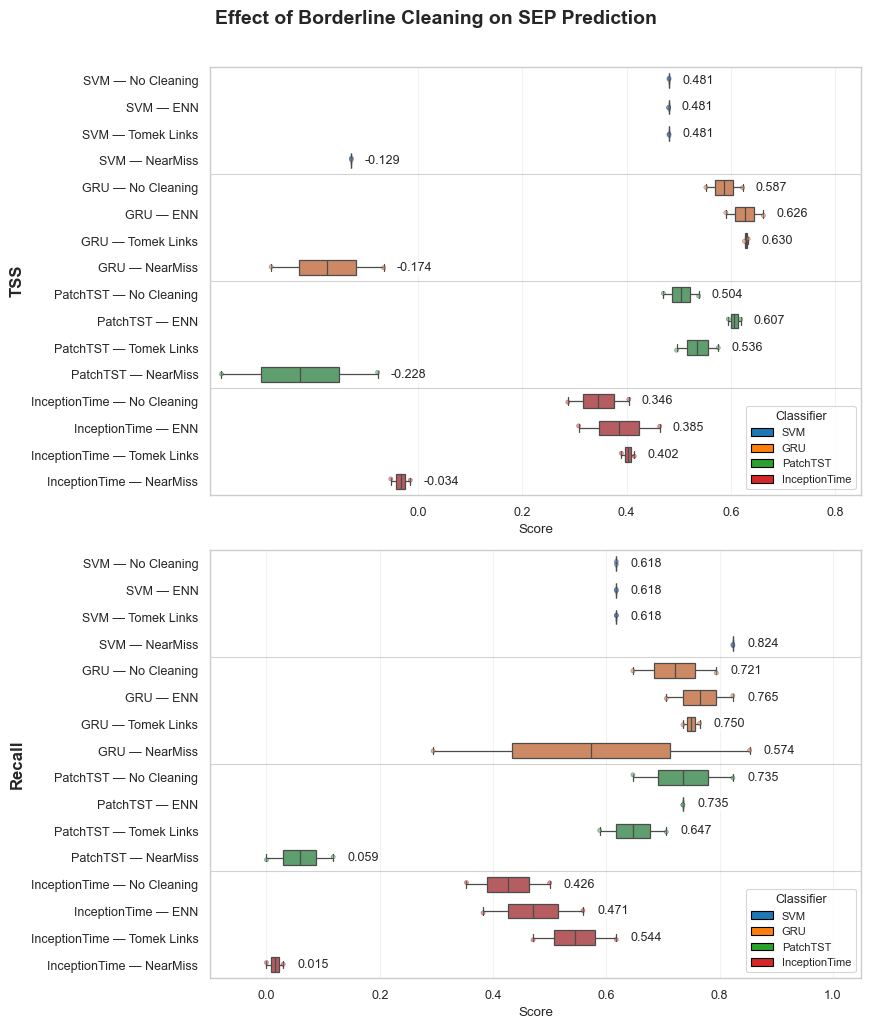

In [28]:
# ══════════════════════════════════════════════════════════════
# BORDERLINE CLEANING EFFECT
# Uses existing plot_df only
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

figure_key = "3_borderline_cleaning"

figure_df = plot_df[
    plot_df["category_key"] == figure_key
].copy()

figure_df["method"] = figure_df["method"].replace({
    "Hybrid baseline": "No Cleaning"
})

method_order = [
    "No Cleaning",
    "ENN",
    "Tomek Links",
    "NearMiss"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

group_order = []
for clf in classifier_order:
    for method in method_order:
        group_order.append(f"{clf} — {method}")

figure_df["group_label"] = (
    figure_df["classifier_label"].astype(str)
    + " — "
    + figure_df["method"].astype(str)
)

figure_df["group_label"] = pd.Categorical(
    figure_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Borderline cleaning figure rows:", len(figure_df))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8.8, 10.5),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = figure_df[
        figure_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.55,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=3,
        alpha=0.55,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("group_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.4, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=9.0,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.80,
                    pad=0.9
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    group_size = len(method_order)
    for sep in [group_size - 0.5, 2 * group_size - 0.5, 3 * group_size - 0.5]:
        ax.axhline(
            sep,
            color="gray",
            linewidth=0.8,
            alpha=0.35
        )

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Effect of Borderline Cleaning on SEP Prediction",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "borderline_cleaning_effect_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "borderline_cleaning_effect_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Random undersampling figure rows: 96
Saved PDF: ./figures_final_pipeline/random_undersampling_effect_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/random_undersampling_effect_sep_prediction.png


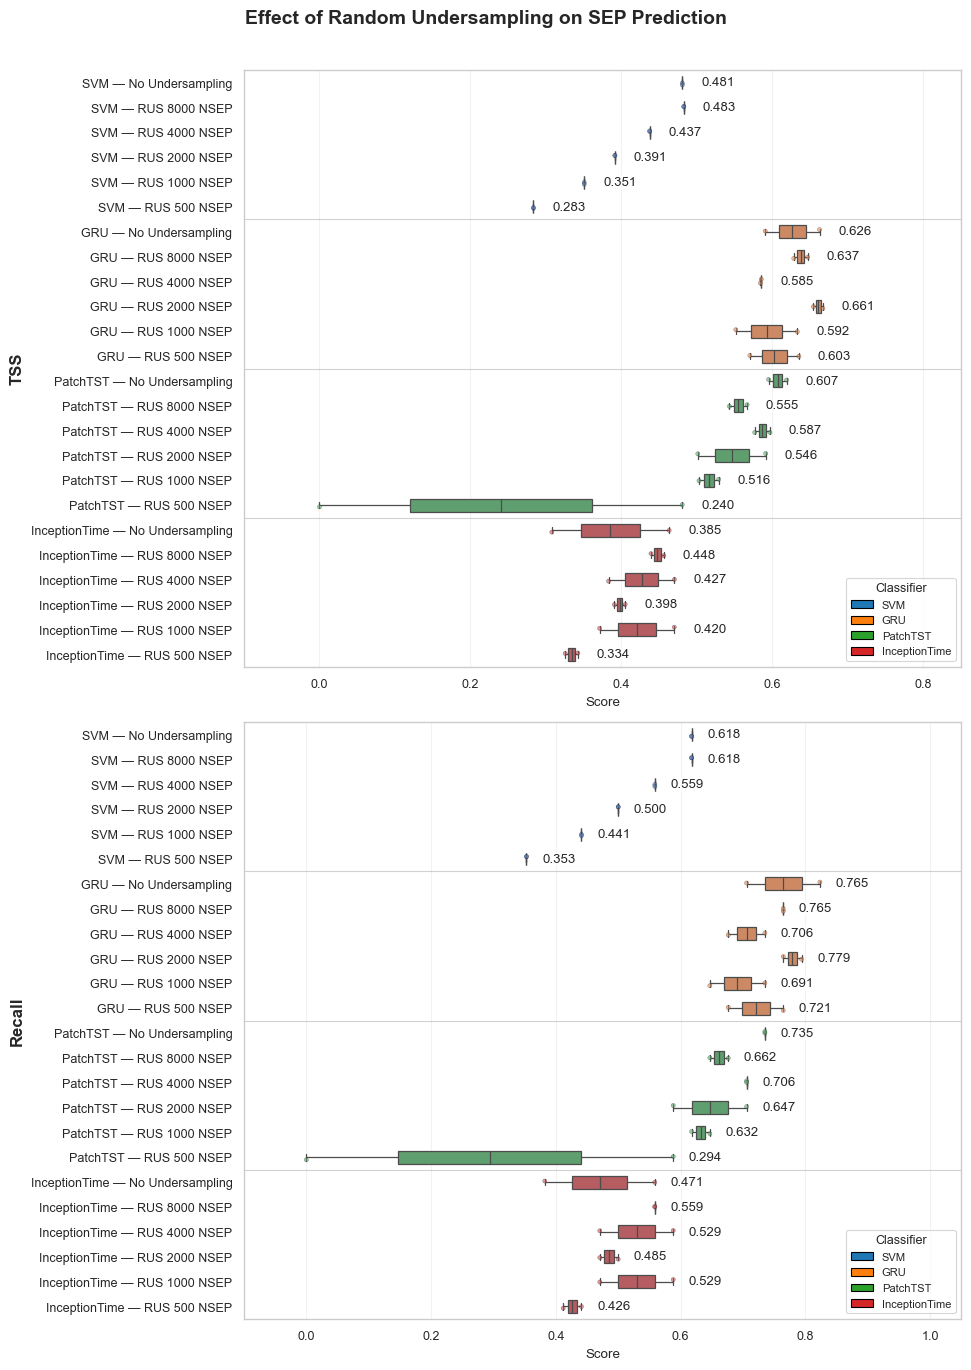

In [29]:
# ══════════════════════════════════════════════════════════════
# RANDOM UNDERSAMPLING EFFECT
# Uses existing plot_df only
# Layout:
#   Top panel    : TSS
#   Bottom panel : Recall
#   Left label   : TSS / Recall
#   Colors       : classifiers
#   Text         : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

figure_key = "4_random_undersampling"

figure_df = plot_df[
    plot_df["category_key"] == figure_key
].copy()

figure_df["method"] = figure_df["method"].replace({
    "ENN baseline": "No Undersampling",
    "RUS 8000": "RUS 8000 NSEP",
    "RUS 4000": "RUS 4000 NSEP",
    "RUS 2000": "RUS 2000 NSEP",
    "RUS 1000": "RUS 1000 NSEP",
    "RUS 500": "RUS 500 NSEP",
})

method_order = [
    "No Undersampling",
    "RUS 8000 NSEP",
    "RUS 4000 NSEP",
    "RUS 2000 NSEP",
    "RUS 1000 NSEP",
    "RUS 500 NSEP"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

group_order = []
for clf in classifier_order:
    for method in method_order:
        group_order.append(f"{clf} — {method}")

figure_df["group_label"] = (
    figure_df["classifier_label"].astype(str)
    + " — "
    + figure_df["method"].astype(str)
)

figure_df["group_label"] = pd.Categorical(
    figure_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Random undersampling figure rows:", len(figure_df))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9.8, 14.0),
    sharex=False
)

for ax, metric in zip(axes, ["TSS", "Recall"]):

    df_metric = figure_df[
        figure_df["metric"] == metric
    ].copy()

    sns.boxplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        width=0.52,
        showfliers=True,
        linewidth=0.9,
        legend=False
    )

    sns.stripplot(
        data=df_metric,
        y="group_label",
        x="score",
        hue="classifier_label",
        order=group_order,
        hue_order=classifier_order,
        orient="h",
        ax=ax,
        dodge=False,
        size=3,
        alpha=0.55,
        linewidth=0.25,
        edgecolor="black",
        legend=False
    )

    # -----------------------------------------------------
    # Add mean value after each box/whisker
    # -----------------------------------------------------

    stats_values = (
        df_metric
        .groupby("group_label", observed=False)["score"]
        .agg(["mean", "max"])
        .reindex(group_order)
    )

    if metric == "TSS":
        ax.set_xlim(-0.1, 0.85)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
        text_offset = 0.025
        max_text_x = 0.825
    else:
        ax.set_xlim(-0.1, 1.05)
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        text_offset = 0.025
        max_text_x = 1.025

    for y_pos, label in enumerate(group_order):
        mean_score = stats_values.loc[label, "mean"]
        max_score = stats_values.loc[label, "max"]

        if pd.notna(mean_score) and pd.notna(max_score):
            text_x = min(max_score + text_offset, max_text_x)

            ax.text(
                text_x,
                y_pos,
                f"{mean_score:.3f}",
                va="center",
                ha="left",
                fontsize=9.5,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.80,
                    pad=0.9
                )
            )

    ax.set_xlabel("Score")
    ax.set_ylabel(metric, fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.25)

    group_size = len(method_order)
    for sep in [group_size - 0.5, 2 * group_size - 0.5, 3 * group_size - 0.5]:
        ax.axhline(
            sep,
            color="gray",
            linewidth=0.8,
            alpha=0.35
        )

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    legend_handles = [
        Patch(
            facecolor=classifier_colors[clf],
            edgecolor="black",
            label=clf
        )
        for clf in classifier_order
    ]

    ax.legend(
        handles=legend_handles,
        title="Classifier",
        loc="lower right",
        fontsize=8,
        title_fontsize=9,
        frameon=True
    )

fig.suptitle(
    "Effect of Random Undersampling on SEP Prediction",
    fontsize=14,
    fontweight="bold",
    y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

pdf_path = os.path.join(FIGURE_DIR, "random_undersampling_effect_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "random_undersampling_effect_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()

Oversampling + RUS figure rows: 288
Saved PDF: ./figures_final_pipeline/oversampling_rus_effect_sep_prediction.pdf
Saved PNG: ./figures_final_pipeline/oversampling_rus_effect_sep_prediction.png


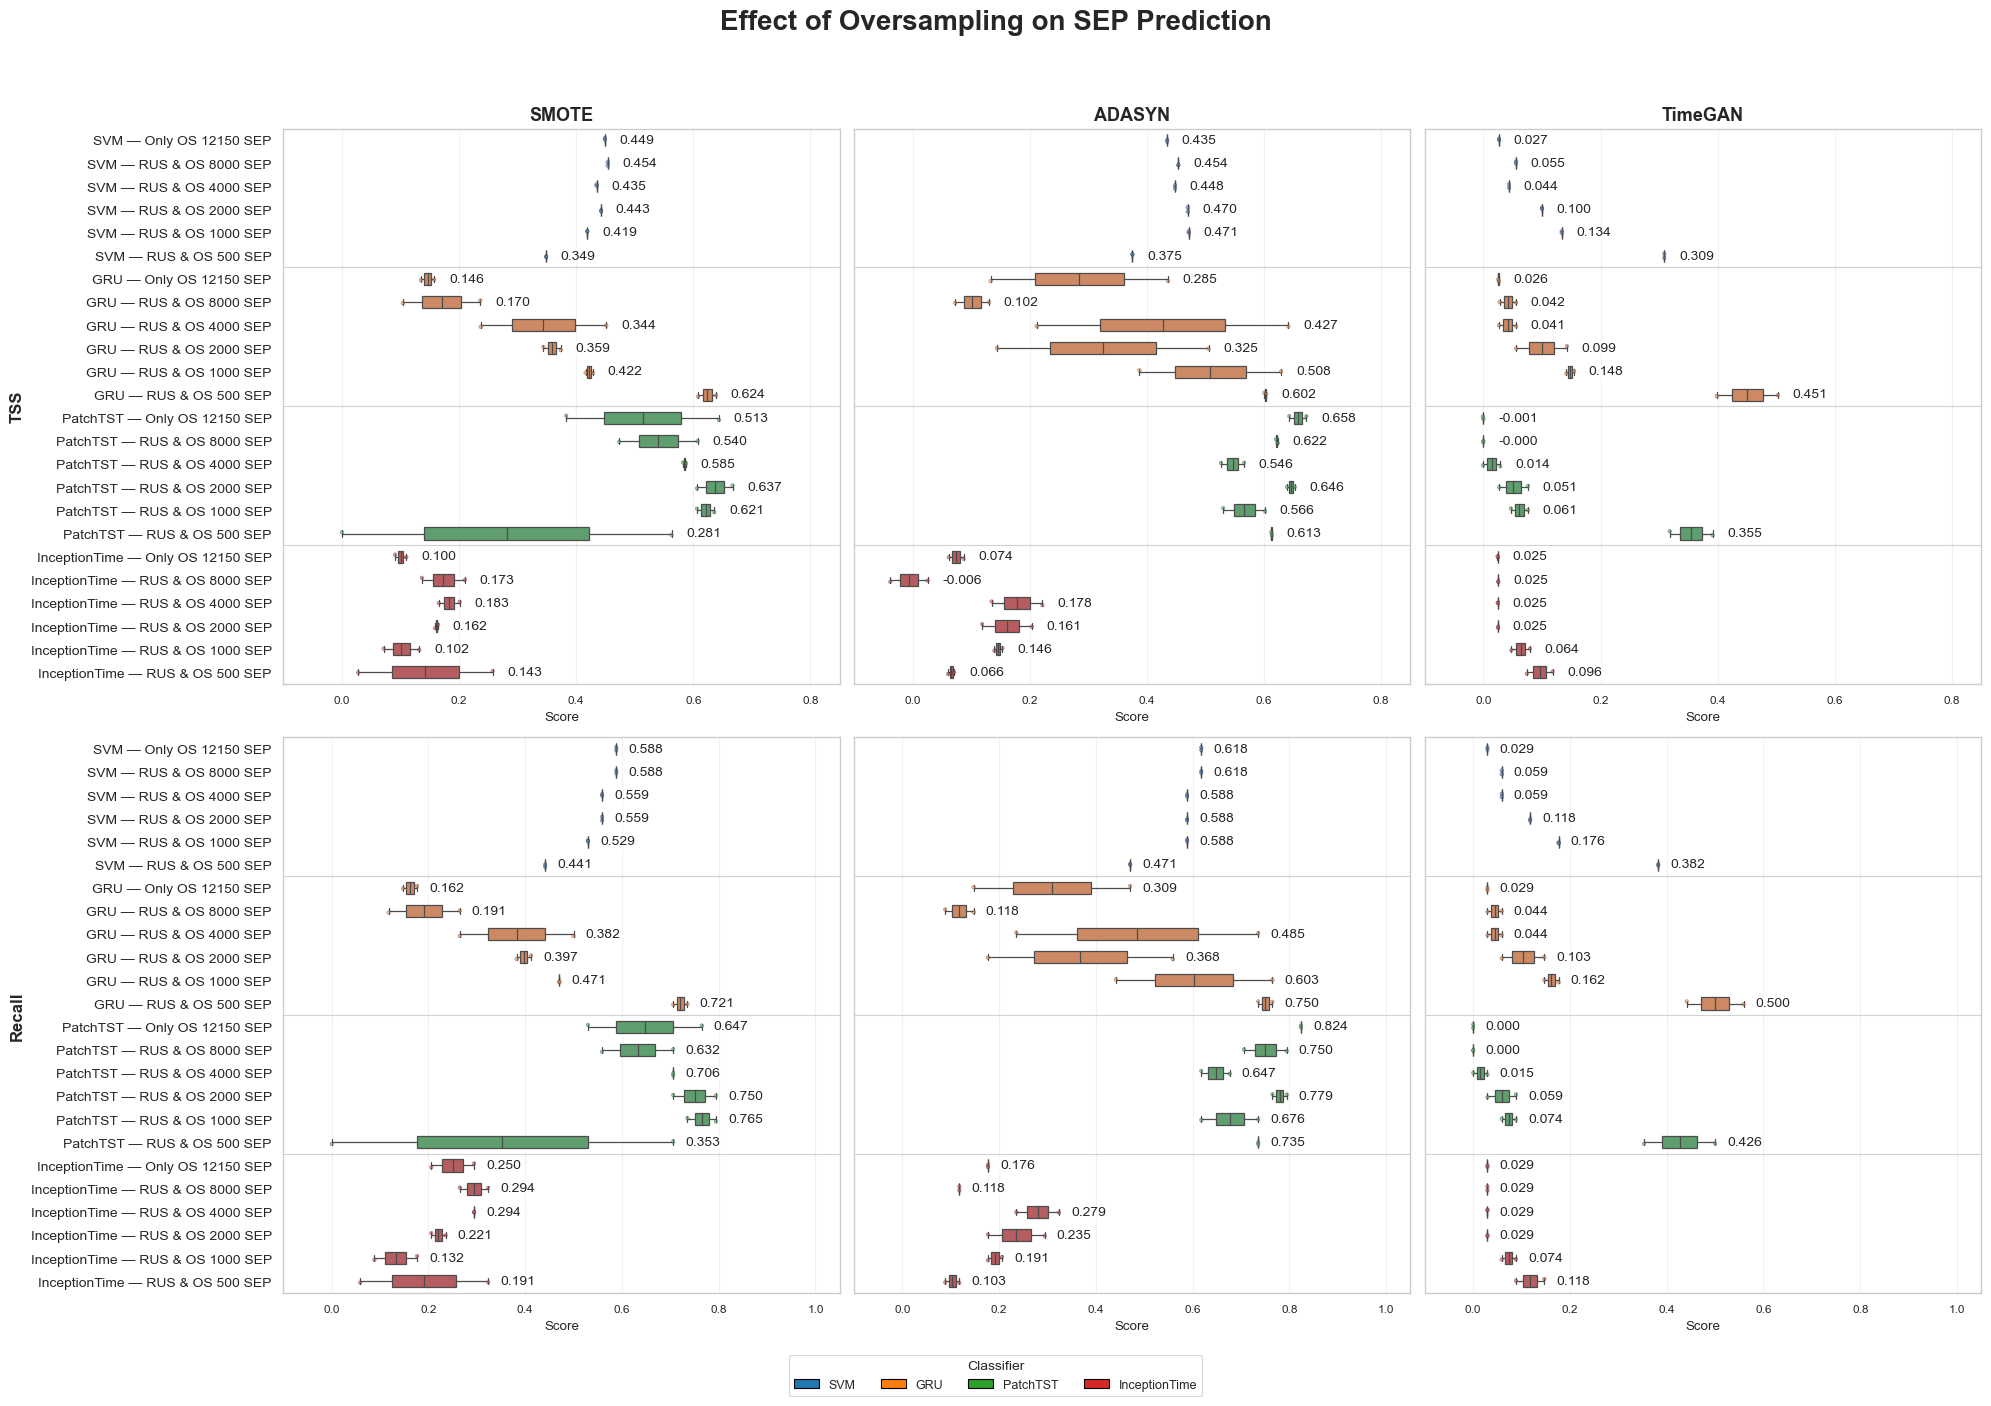

In [30]:
# ══════════════════════════════════════════════════════════════
# OVERSAMPLING + RUS EFFECT
# Uses existing plot_df only
# Layout:
#   Rows    : TSS, Recall
#   Columns : SMOTE, ADASYN, TimeGAN
#   Y-axis  : Classifier — oversampling/RUS variant
#   Colors  : classifiers
#   Text    : mean score shown after each box/whisker
# Output:
#   PDF + PNG
# ══════════════════════════════════════════════════════════════

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

figure_key = "5_oversampling_and_rus"

figure_df = plot_df[
    plot_df["category_key"] == figure_key
].copy()

# ---------------------------------------------------------
# Clean method labels
# ---------------------------------------------------------

def get_oversampler(method):
    if method.startswith("SMOTE"):
        return "SMOTE"
    if method.startswith("ADASYN"):
        return "ADASYN"
    if method.startswith("TimeGAN"):
        return "TimeGAN"
    return None


def get_variant_label(method):
    if "balanced" in method:
        return "Only OS 12150 SEP"
    if "8000" in method:
        return "RUS & OS 8000 SEP"
    if "4000" in method:
        return "RUS & OS 4000 SEP"
    if "2000" in method:
        return "RUS & OS 2000 SEP"
    if "1000" in method:
        return "RUS & OS 1000 SEP"
    if "500" in method:
        return "RUS & OS 500 SEP"
    return method


figure_df["oversampler"] = figure_df["method"].apply(get_oversampler)
figure_df["variant"] = figure_df["method"].apply(get_variant_label)

figure_df = figure_df[
    figure_df["oversampler"].isin(["SMOTE", "ADASYN", "TimeGAN"])
].copy()

oversampler_order = [
    "SMOTE",
    "ADASYN",
    "TimeGAN"
]

variant_order = [
    "Only OS 12150 SEP",
    "RUS & OS 8000 SEP",
    "RUS & OS 4000 SEP",
    "RUS & OS 2000 SEP",
    "RUS & OS 1000 SEP",
    "RUS & OS 500 SEP"
]

classifier_order = [
    "SVM",
    "GRU",
    "PatchTST",
    "InceptionTime"
]

group_order = []
for clf in classifier_order:
    for variant in variant_order:
        group_order.append(f"{clf} — {variant}")

figure_df["group_label"] = (
    figure_df["classifier_label"].astype(str)
    + " — "
    + figure_df["variant"].astype(str)
)

figure_df["group_label"] = pd.Categorical(
    figure_df["group_label"],
    categories=group_order,
    ordered=True
)

palette = sns.color_palette("tab10", n_colors=len(classifier_order))
classifier_colors = {
    clf: palette[i]
    for i, clf in enumerate(classifier_order)
}

print("Oversampling + RUS figure rows:", len(figure_df))

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(20, 14),
    sharey=True,
    sharex=False
)

for row_idx, metric in enumerate(["TSS", "Recall"]):

    for col_idx, oversampler in enumerate(oversampler_order):

        ax = axes[row_idx, col_idx]

        df_panel = figure_df[
            (figure_df["metric"] == metric) &
            (figure_df["oversampler"] == oversampler)
        ].copy()

        sns.boxplot(
            data=df_panel,
            y="group_label",
            x="score",
            hue="classifier_label",
            order=group_order,
            hue_order=classifier_order,
            orient="h",
            ax=ax,
            width=0.52,
            showfliers=True,
            linewidth=0.9,
            legend=False
        )

        sns.stripplot(
            data=df_panel,
            y="group_label",
            x="score",
            hue="classifier_label",
            order=group_order,
            hue_order=classifier_order,
            orient="h",
            ax=ax,
            dodge=False,
            size=2.6,
            alpha=0.55,
            linewidth=0.25,
            edgecolor="black",
            legend=False
        )

        # -------------------------------------------------
        # Add mean value after each box/whisker
        # -------------------------------------------------

        stats_values = (
            df_panel
            .groupby("group_label", observed=False)["score"]
            .agg(["mean", "max"])
            .reindex(group_order)
        )

        if metric == "TSS":
            ax.set_xlim(-0.1, 0.85)
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8])
            text_offset = 0.025
            max_text_x = 0.825
        else:
            ax.set_xlim(-0.1, 1.05)
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            text_offset = 0.025
            max_text_x = 1.025

        for y_pos, label in enumerate(group_order):
            mean_score = stats_values.loc[label, "mean"]
            max_score = stats_values.loc[label, "max"]

            if pd.notna(mean_score) and pd.notna(max_score):
                text_x = min(max_score + text_offset, max_text_x)

                ax.text(
                    text_x,
                    y_pos,
                    f"{mean_score:.3f}",
                    va="center",
                    ha="left",
                    fontsize=10,
                    bbox=dict(
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.80,
                        pad=0.9
                    )
                )

        if row_idx == 0:
            ax.set_title(
                oversampler,
                fontsize=13,
                fontweight="bold"
            )
        else:
            ax.set_title("")

        ax.set_xlabel("Score")
        ax.grid(True, axis="x", alpha=0.25)

        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)

        group_size = len(variant_order)
        for sep in [group_size - 0.5, 2 * group_size - 0.5, 3 * group_size - 0.5]:
            ax.axhline(
                sep,
                color="gray",
                linewidth=0.8,
                alpha=0.35
            )

        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=8.5)

legend_handles = [
    Patch(
        facecolor=classifier_colors[clf],
        edgecolor="black",
        label=clf
    )
    for clf in classifier_order
]

fig.legend(
    handles=legend_handles,
    title="Classifier",
    loc="lower center",
    ncol=4,
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Effect of Oversampling on SEP Prediction",
    fontsize=20,
    fontweight="bold",
    y=0.985
)

plt.tight_layout(rect=[0, 0.03, 1, 0.955])

pdf_path = os.path.join(FIGURE_DIR, "oversampling_rus_effect_sep_prediction.pdf")
png_path = os.path.join(FIGURE_DIR, "oversampling_rus_effect_sep_prediction.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

plt.show()